In [16]:
from dataclasses import dataclass
import numpy as np

@dataclass
class Grid:
    rows: int
    cols: int
    step_reward: int
    terminals: dict
    walls: set
    actions = dict(up=(-1, 0), right=(0, 1), down=(1, 0), left=(0, -1))
    arrows = {'up': "↑", 'right': "→", 'down': "↓", 'left': "←"}
    def cell_repr(self, r, c):
        cell = (r, c)
        if cell in self.terminals:
            return self.terminals[cell]
        elif cell in self.walls:
            return '#'
        else:
            return '·'
    def render(self):
        for r in range(self.rows):
            for c in range(self.cols):
                print(f'{self.cell_repr(r, c):>3} ', end="")
            print()

    def step(self, cell, action):
        movement = self.actions[action]
        next_cell = (cell[0] + movement[0], cell[1] + movement[1])
        outside = not (0 <= next_cell[0] < self.rows and 0 <= next_cell[1] < self.cols)
        on_wall = next_cell in self.walls
        if outside or on_wall:
            next_cell = cell

        if next_cell in self.terminals:
            reward = self.terminals[next_cell]
        else:
            reward = self.step_reward
        return next_cell, reward
    def properties(self):
        return f'''
Grid(
    rows={self.rows},
    cols={self.cols},
    step_reward={self.step_reward},
    terminals={self.terminals},
    walls={self.walls},
)
'''


default_grid = Grid(
    rows=3,
    cols=4,
    step_reward=0,
    terminals={(0, 3): 1},
    walls={(1, 1)},
)
default_grid

Grid(rows=3, cols=4, step_reward=0, terminals={(0, 3): 1}, walls={(1, 1)})

In [17]:
import io, contextlib, functools

def silent(fn):
    @functools.wraps(fn)
    def wrapper(*args, **kwargs):
        with contextlib.redirect_stdout(io.StringIO()):
            return fn(*args, **kwargs)
    return wrapper

In [18]:
def render_policy(grid: Grid, policy):
    for r in range(len(policy)):
        for c in range(len(policy[0])):
            if r == 0 and c == 0:
                print("r/c", end="")
                print(''.join([f'{v:>2} ' for v in range(grid.cols)]))
            if c == 0:
                print(f'{r:>2} ', end="")

            if policy[r][c] != None:
                value = grid.arrows[max(policy[r][c], key=policy[r][c].get)]
            else:
                value = grid.cell_repr(r, c)
            print(f' {value} ', end='')
        print()
    print('------------------')

def show_V(grid: Grid, V):
    for r in range(grid.rows):
        for c in range(grid.cols):
            if r == 0 and c == 0:
                print("  r/c", end="")
                print(''.join([f'{v:>4} ' for v in range(grid.cols)]))
            if c == 0:
                print(f'{r:>4} ', end="")
            print(f'{round(V[r][c], 2):>4} ', end="")
        print()
    print('------------------')


def value_iteration(grid: Grid, gamma=0.9, theta=1e-6, max_iters=1000):
    print('---------- value_iteration ------------')
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    policy = [[None for _ in range(grid.cols)] for _ in range(grid.rows)]
    delta = float('inf')
    i = 0
    while delta > theta and i < max_iters:
        delta = 0.0
        V_old = [row[:] for row in V]
        for r in range(grid.rows):
            for c in range(grid.cols):
                cell = (r, c)
                if cell in grid.walls or cell in grid.terminals:
                    continue
                def q(action):
                    next_cell, reward = grid.step(cell, action)
                    return reward + gamma * V_old[next_cell[0]][next_cell[1]]
                new_value = float('-inf')
                for action in grid.actions:
                    value = q(action)
                    if value > new_value:
                        new_value = value
                        policy[r][c] = {action: 1.0}
                V[r][c] = new_value
                delta = max(delta, abs(V[r][c] - V_old[r][c]))
        show_V(grid, V)
        i += 1
    render_policy(grid, policy)
    converged = delta <= theta
    if converged:
        print(f'value_iteration converged in {i} iterations')
    else:
        print(f'value_iteration did not converge in {max_iters} iterations')
    return policy, V, converged

In [19]:
policy, V, converged = value_iteration(default_grid);

---------- value_iteration ------------
  r/c   0    1    2    3 
   0  0.0  0.0  1.0    0 
   1  0.0    0  0.0  1.0 
   2  0.0  0.0  0.0  0.0 
------------------
  r/c   0    1    2    3 
   0  0.0  0.9  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0  0.0  0.0  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0  0.0 0.81  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2  0.0 0.73 0.81  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  ↑ 
 2  ↑  →  ↑  ↑ 
------------------
value_iteration converged in 6 iterations


In [20]:
def read_policy(grid: Grid, V, gamma=0.9, incumbent_policy=None):
    policy = [[None for _ in range(grid.cols)] for _ in range(grid.rows)]
    for r in range(grid.rows):
        for c in range(grid.cols):
            cell = (r, c)
            if cell in grid.walls or cell in grid.terminals:
                continue
            def q(action):
                next_cell, reward = grid.step(cell, action)
                return reward + gamma * V[next_cell[0]][next_cell[1]]
            new_action = max(grid.actions, key=q)
            if incumbent_policy:
                incumbent_action = max(incumbent_policy[r][c], key=incumbent_policy[r][c].get)
                if q(new_action) - q(incumbent_action) < 1e-9:
                    new_action = incumbent_action
            policy[r][c] = {new_action: 1.0}
    return policy


policy = read_policy(default_grid, V)
policy

[[{'right': 1.0}, {'right': 1.0}, {'right': 1.0}, None],
 [{'up': 1.0}, None, {'up': 1.0}, {'up': 1.0}],
 [{'up': 1.0}, {'right': 1.0}, {'up': 1.0}, {'up': 1.0}]]

In [21]:
render_policy(default_grid, policy)

r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  ↑ 
 2  ↑  →  ↑  ↑ 
------------------


In [22]:
def policy_evaluation(
    grid: Grid, policy, gamma=0.9, theta=1e-6, verbose=False, max_iters=1000
):
    if verbose:
        print('---------- policy_evaluation ------------')
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    delta = float('inf')
    i = 0
    while delta > theta and i < max_iters:
        delta = 0.0
        V_old = [row[:] for row in V]
        for r in range(grid.rows):
            for c in range(grid.cols):
                cell = (r, c)
                if cell in grid.walls or cell in grid.terminals:
                    continue
                value = 0
                for action, prob in policy[r][c].items():
                    next_cell, reward = grid.step(cell, action)
                    value += prob * (reward + gamma * V_old[next_cell[0]][next_cell[1]])
                V[r][c] = value
                delta = max(delta, abs(V[r][c] - V_old[r][c]))
        if verbose:
            show_V(grid, V)
        i += 1
    converged = delta <= theta
    if converged:
        print(f'policy_evaluation converged in {i} iterations')
    else:
        print(f'policy_evaluation did not converge in {max_iters} iterations')
    return V, converged


policy_evaluation(default_grid, policy, verbose=True);

---------- policy_evaluation ------------
  r/c   0    1    2    3 
   0  0.0  0.0  1.0    0 
   1  0.0    0  0.0  1.0 
   2  0.0  0.0  0.0  0.0 
------------------
  r/c   0    1    2    3 
   0  0.0  0.9  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0  0.0  0.0  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0  0.0 0.81  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2  0.0 0.73 0.81  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
policy_evaluation converged in 6 iterations


In [23]:
def policy_iteration(
    grid: Grid,
    policy=None,
    max_iters=1000,
    pass_incumbent_policy=False,
    gamma=0.9,
    theta=1e-6,
    policy_evaluation_verbose=False,
    policy_evaluation_max_iters=1000,
    eps = None,
):
    print('---------- policy_iteration ------------')
    if policy is None:
        policy = [[{'up': 1.0} for _ in range(grid.cols)] for _ in range(grid.rows)]
    i = 0
    policy_evaluation_converged = True
    changed = None
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    while changed != 0 and i < max_iters:
        V, policy_evaluation_converged = policy_evaluation(
            grid,
            policy if eps is None else eps_soft(grid, policy, eps),
            gamma,
            theta,
            verbose=policy_evaluation_verbose,
            max_iters=policy_evaluation_max_iters,
        )
        if not policy_evaluation_converged:
            break
        show_V(grid, V)
        new_policy = read_policy(
            grid, V, gamma, incumbent_policy=policy if pass_incumbent_policy else None
        )
        changed = sum(
            new_policy[r][c] != None
            and (
                max(new_policy[r][c], key=new_policy[r][c].get)
                != max(policy[r][c], key=policy[r][c].get)
            )
            for r in range(grid.rows)
            for c in range(grid.cols)
        )
        print(f'actions changed = {changed}')
        render_policy(grid, new_policy)
        policy = new_policy
        i += 1
    converged = changed == 0
    if not policy_evaluation_converged:
        print(
            f"policy_iteration did not converge because policy_evaluation did not converge"
        )
    elif converged:
        print(f'policy_iteration converged in {i} iterations')
    else:
        print(f'policy_iteration did not converge in {max_iters} iterations')
    return policy, V, converged

In [24]:
policy_iteration(default_grid);

---------- policy_iteration ------------
policy_evaluation converged in 3 iterations
  r/c   0    1    2    3 
   0  0.0  0.0  0.0    0 
   1  0.0    0  0.0  1.0 
   2  0.0  0.0  0.0  0.9 
------------------
actions changed = 3
r/c 0  1  2  3 
 0  ↑  ↑  →  1 
 1  ↑  #  →  ↑ 
 2  ↑  ↑  →  ↑ 
------------------
policy_evaluation converged in 4 iterations
  r/c   0    1    2    3 
   0  0.0  0.0  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0  0.0 0.81  0.9 
------------------
actions changed = 4
r/c 0  1  2  3 
 0  ↑  →  →  1 
 1  ↑  #  ↑  ↑ 
 2  ↑  →  ↑  ↑ 
------------------
policy_evaluation converged in 5 iterations
  r/c   0    1    2    3 
   0  0.0  0.9  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0 0.73 0.81  0.9 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  ↑ 
 2  →  →  ↑  ↑ 
------------------
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
-

In [25]:
policy_iteration(default_grid, pass_incumbent_policy=True);

---------- policy_iteration ------------
policy_evaluation converged in 3 iterations
  r/c   0    1    2    3 
   0  0.0  0.0  0.0    0 
   1  0.0    0  0.0  1.0 
   2  0.0  0.0  0.0  0.9 
------------------
actions changed = 3
r/c 0  1  2  3 
 0  ↑  ↑  →  1 
 1  ↑  #  →  ↑ 
 2  ↑  ↑  →  ↑ 
------------------
policy_evaluation converged in 4 iterations
  r/c   0    1    2    3 
   0  0.0  0.0  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0  0.0 0.81  0.9 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  ↑  →  →  1 
 1  ↑  #  →  ↑ 
 2  ↑  →  →  ↑ 
------------------
policy_evaluation converged in 5 iterations
  r/c   0    1    2    3 
   0  0.0  0.9  1.0    0 
   1  0.0    0  0.9  1.0 
   2  0.0 0.73 0.81  0.9 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  →  ↑ 
 2  →  →  →  ↑ 
------------------
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
-

In [26]:
uniform_policy = [
    [
        {a: 1 / len(default_grid.actions) for a in default_grid.actions}
        for _ in range(default_grid.cols)
    ]
    for _ in range(default_grid.rows)
]
uniform_policy

[[{'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25}],
 [{'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25}],
 [{'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25}]]

In [27]:
policy_iteration(
    default_grid,
    policy=uniform_policy,
);

---------- policy_iteration ------------
policy_evaluation converged in 80 iterations
  r/c   0    1    2    3 
   0 0.15 0.27 0.51    0 
   1  0.1    0 0.37 0.52 
   2  0.1 0.14 0.24 0.31 
------------------
actions changed = 6
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  →  ↑ 
 2  →  →  ↑  ↑ 
------------------
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  ↑ 
 2  ↑  →  ↑  ↑ 
------------------
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
actions changed = 0
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  ↑ 
 2  ↑  →  ↑  ↑ 
------------------
policy_iteration converged in 3 iterations


In [28]:
policy_iteration(
    default_grid,
    policy=uniform_policy,
    pass_incumbent_policy=True
);

---------- policy_iteration ------------
policy_evaluation converged in 80 iterations
  r/c   0    1    2    3 
   0 0.15 0.27 0.51    0 
   1  0.1    0 0.37 0.52 
   2  0.1 0.14 0.24 0.31 
------------------
actions changed = 6
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  →  ↑ 
 2  →  →  ↑  ↑ 
------------------
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.81  0.9  1.0    0 
   1 0.73    0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------
actions changed = 0
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  →  ↑ 
 2  →  →  ↑  ↑ 
------------------
policy_iteration converged in 2 iterations


In [29]:
import numpy as np

def analytic_policy_value(grid: Grid, policy, gamma = 0.9):
    cell2s = lambda cell: cell[0] * grid.cols + cell[1]
    s2cell = lambda s: (s // grid.cols, s % grid.cols)
    
    n = grid.rows * grid.cols
    Ppi = np.zeros((n, n))
    rpi = np.zeros(n)
    for s in range(n):
        cell = s2cell(s)
        if policy[cell[0]][cell[1]] is None:
            continue
        for action, pa in policy[cell[0]][cell[1]].items():
            next_cell, r = grid.step(cell, action)
            ns = cell2s(next_cell)
            prob = 1.0
            Ppi[s, ns] += pa * prob
            rpi[s] += pa * prob * r
    V_solve = np.linalg.solve(np.eye(n) - gamma * Ppi, rpi)
    V = [[0 for _ in range(grid.cols)] for _ in range(grid.rows)]
    for s in range(n):
        cell = s2cell(s)
        V[cell[0]][cell[1]] = float(V_solve[s])
    return V
V = analytic_policy_value(default_grid, policy, 0.9)
show_V(default_grid, V)

  r/c   0    1    2    3 
   0 0.81  0.9  1.0  0.0 
   1 0.73  0.0  0.9  1.0 
   2 0.66 0.73 0.81  0.9 
------------------


## Experiments

## ε-greedy evaluation next to a pit 

In [ ]:
grid = Grid(
    rows=3,
    cols=4,
    step_reward=-0.04,
    terminals={(0, 3): 1, (1, 3): -1},
    walls={(1, 1)},
)

In [ ]:
grid.render()

  ·   ·   ·   1 
  ·   #   ·  -1 
  ·   ·   ·   · 


In [ ]:
pi_star, V, converged = value_iteration(grid)

---------- value_iteration ------------
  r/c   0    1    2    3 
   0 -0.04 -0.04  1.0    0 
   1 -0.04    0 -0.04    0 
   2 -0.04 -0.04 -0.04 -0.04 
------------------
  r/c   0    1    2    3 
   0 -0.08 0.86  1.0    0 
   1 -0.08    0 0.86    0 
   2 -0.08 -0.08 -0.08 -0.08 
------------------
  r/c   0    1    2    3 
   0 0.73 0.86  1.0    0 
   1 -0.11    0 0.86    0 
   2 -0.11 -0.11 0.73 -0.11 
------------------
  r/c   0    1    2    3 
   0 0.73 0.86  1.0    0 
   1 0.62    0 0.86    0 
   2 -0.14 0.62 0.73 0.62 
------------------
  r/c   0    1    2    3 
   0 0.73 0.86  1.0    0 
   1 0.62    0 0.86    0 
   2 0.52 0.62 0.73 0.62 
------------------
  r/c   0    1    2    3 
   0 0.73 0.86  1.0    0 
   1 0.62    0 0.86    0 
   2 0.52 0.62 0.73 0.62 
------------------
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
value_iteration converged in 6 iterations


In [ ]:
pi_star

[[{'right': 1.0}, {'right': 1.0}, {'right': 1.0}, None],
 [{'up': 1.0}, None, {'up': 1.0}, None],
 [{'up': 1.0}, {'right': 1.0}, {'up': 1.0}, {'left': 1.0}]]

In [ ]:
def eps_soft(grid: Grid, policy, eps=0.1):
    policy = [row[:] for row in policy]
    action_keys = list(grid.actions.keys())
    n_actions = len(action_keys)
    for r in range(grid.rows):
        for c in range(grid.cols):
            if policy[r][c] is None:
                continue
            ga = max(policy[r][c], key=policy[r][c].get)
            other_actions = {
                action: eps / n_actions
                for action in action_keys
                if action != ga
            }
            greedy_action = {
                ga: 1.0 - eps + eps / n_actions,
            }
            policy[r][c] = {**greedy_action, **other_actions}

    return policy

In [ ]:
new_policy = eps_soft(grid, pi_star, eps=0.9)
new_policy

[[{'right': 0.32499999999999996, 'up': 0.225, 'down': 0.225, 'left': 0.225},
  {'right': 0.32499999999999996, 'up': 0.225, 'down': 0.225, 'left': 0.225},
  {'right': 0.32499999999999996, 'up': 0.225, 'down': 0.225, 'left': 0.225},
  None],
 [{'up': 0.32499999999999996, 'right': 0.225, 'down': 0.225, 'left': 0.225},
  None,
  {'up': 0.32499999999999996, 'right': 0.225, 'down': 0.225, 'left': 0.225},
  None],
 [{'up': 0.32499999999999996, 'right': 0.225, 'down': 0.225, 'left': 0.225},
  {'right': 0.32499999999999996, 'up': 0.225, 'down': 0.225, 'left': 0.225},
  {'up': 0.32499999999999996, 'right': 0.225, 'down': 0.225, 'left': 0.225},
  {'left': 0.32499999999999996, 'up': 0.225, 'right': 0.225, 'down': 0.225}]]

In [ ]:
render_policy(grid, new_policy)

r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------


In [ ]:
sum(new_policy[0][0].values())

1.0

In [ ]:
new_policy = eps_soft(grid, pi_star, eps=1)
new_policy

[[{'right': 0.25, 'up': 0.25, 'down': 0.25, 'left': 0.25},
  {'right': 0.25, 'up': 0.25, 'down': 0.25, 'left': 0.25},
  {'right': 0.25, 'up': 0.25, 'down': 0.25, 'left': 0.25},
  None],
 [{'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  None,
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  None],
 [{'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'right': 0.25, 'up': 0.25, 'down': 0.25, 'left': 0.25},
  {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25},
  {'left': 0.25, 'up': 0.25, 'right': 0.25, 'down': 0.25}]]

In [ ]:
render_policy(grid, new_policy)

r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------


In [ ]:
V, converged = policy_evaluation(grid, eps_soft(grid, pi_star, eps=0.9));

policy_evaluation converged in 65 iterations


In [ ]:
show_V(grid, V)

  r/c   0    1    2    3 
   0 -0.13 0.04  0.3    0 
   1 -0.24    0 -0.32    0 
   2 -0.32 -0.38 -0.43 -0.64 
------------------


In [ ]:
policy = read_policy(grid, V)
policy

[[{'right': 1.0}, {'right': 1.0}, {'right': 1.0}, None],
 [{'up': 1.0}, None, {'up': 1.0}, None],
 [{'up': 1.0}, {'left': 1.0}, {'up': 1.0}, {'left': 1.0}]]

In [ ]:
render_policy(grid, pi_star)

r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------


In [ ]:
render_policy(grid, policy)

r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  ←  ↑  ← 
------------------


In [ ]:
for eps in [0, 0.05, 0.1, 0.2, 0.5, 0.9, 1.0]:
    print(f'{eps=}')
    V, converged = policy_evaluation(grid, eps_soft(grid, pi_star, eps=eps));
    show_V(grid, V)
    policy = read_policy(grid, V)
    render_policy(grid, policy)

eps=0
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.73 0.86  1.0    0 
   1 0.62    0 0.86    0 
   2 0.52 0.62 0.73 0.62 
------------------
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
eps=0.05
policy_evaluation converged in 14 iterations
  r/c   0    1    2    3 
   0 0.72 0.85 0.99    0 
   1  0.6    0 0.82    0 
   2  0.5 0.58 0.69 0.56 
------------------
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
eps=0.1
policy_evaluation converged in 17 iterations
  r/c   0    1    2    3 
   0 0.69 0.83 0.98    0 
   1 0.57    0 0.78    0 
   2 0.47 0.54 0.65  0.5 
------------------
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
eps=0.2
policy_evaluation converged in 21 iterations
  r/c   0    1    2    3 
   0 0.65 0.79 0.95    0 
   1 0.52    0  0.7    0 
   2 0.41 0.44 0.56 0.37 
------------------
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -

Fair — let me rebuild it from the bottom.

What V is measuring in each row
-------------------------------

Each row of that table is the answer to a _different_ question. Not "how well do I estimate V\*" — every row is an exact answer, converged to 1e-6. The question changes:

*   **ε=0**: "If I always take π\*'s action, what do I get?" → that's V\*.
*   **ε=0.5**: "If I take π\*'s action only 62.5% of the time and a random one otherwise, what do I get?"

At ε=0.5 with 4 actions, the greedy action's probability is `0.5 + 0.5/4 = 0.625`, and each of the other three gets `0.125`. So the ε=0.5 row is the true expected return of a genuinely clumsy agent — one that stumbles more than a third of the time, every step, forever. Not a noisy estimate of a good agent.

Stumbling costs you two different things
----------------------------------------

**Cost 1 — wasted steps.** A wrong action bumps a wall or walks backward. You pay `-0.04` and try again. Every cell suffers this equally, because wandering is wandering. That's why the far column drops in lockstep: −0.86, −0.86, −0.84.

**Cost 2 — falling in the pit.** This only exists if a wrong action can land you on (1,3). It doesn't cost you a step — it ends the episode at −1. You never reach the +1 at all.

So, roughly:

    V^eps(s)  =  V*(s)  -  (wandering tax, everywhere)  -  (pit risk, only near the pit)
    

At ε=0.9 the far column loses ~0.85 and the pit cells lose ~1.2. The extra ~0.35 is cost 2.

Why (2,3) specifically
----------------------

(2,3) sits directly below the pit:

     ·  ·  ·  +1
     ·  #  ·  -1     <- pit at (1,3)
     ·  ·  ·   ·     <- (2,3) is here, right underneath
    

π\* tells it to go `left`. But under ε-greedy, `up` gets probability `ε/4` — at ε=0.5 that's **12.5% per visit**, and `up` from (2,3) is the pit. So on average one visit in eight ends the episode at −1.

Contrast (2,0) in the far column. Its wrong actions bump the left wall or step into empty cells. Cost: `-0.04` and some lost time. Nothing catastrophic is reachable.

Same amount of randomness. Wildly different consequence.

The crossover, restated
-----------------------

    eps=0     (2,3)=0.62   (2,0)=0.52     (2,3) wins
    eps=0.2   (2,3)=0.37   (2,0)=0.41     (2,0) wins
    

At ε=0, (2,3) is the better place to be — it's 2 steps from the goal, (2,0) is 4. That head start is worth about 0.10.

As ε rises, both lose to wandering, but (2,3) _additionally_ leaks value into the pit. Once that leak exceeds the 0.10 head start — somewhere around ε≈0.15 — being closer to the goal stops being worth it. **A clumsy agent is better off far away in safe territory than close to the reward but next to a hazard.**

Why this is the SARSA/Q-learning split
--------------------------------------

Those are two different rows of your table:

*   **Q-learning** learns V\* — the ε=0 row. It answers "what's this worth assuming I act perfectly from here." It says (2,3) is worth 0.62.
*   **SARSA** learns V^ε-greedy — the ε=0.5 row. It answers "what's this worth given I'll keep exploring." It says (2,3) is worth −0.07.

SARSA's numbers _include_ the cost of its own clumsiness, so it routes away from the pit while learning. Q-learning's don't, so it takes the optimal-if-perfect path and falls in repeatedly during training. Same environment, same ε — different question, different answer.

Your table is that difference, computed exactly, before either algorithm exists.

In [ ]:
policy_iteration(grid, eps=0);

---------- policy_iteration ------------
policy_evaluation converged in 102 iterations
  r/c   0    1    2    3 
   0 -0.4 -0.4 -0.4    0 
   1 -0.4    0 -0.4    0 
   2 -0.4 -0.4 -0.4 -1.0 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  ↑  ↑  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  ↑  ↑  ← 
------------------
policy_evaluation converged in 102 iterations
  r/c   0    1    2    3 
   0 -0.4 -0.4  1.0    0 
   1 -0.4    0 0.86    0 
   2 -0.4 -0.4 0.73 0.62 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  ↑  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
policy_evaluation converged in 102 iterations
  r/c   0    1    2    3 
   0 -0.4 0.86  1.0    0 
   1 -0.4    0 0.86    0 
   2 -0.4 0.62 0.73 0.62 
------------------
actions changed = 2
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  →  →  ↑  ← 
------------------
policy_evaluation converged in 6 iterations
  r/c   0    1    2    3 
   0 0.73 0.86  1.0    0 
   1 0.62    0 0.86    0 
   2 0.52 0.62 0.7

In [ ]:
policy_iteration(grid, eps=0.5);

---------- policy_iteration ------------
policy_evaluation converged in 81 iterations
  r/c   0    1    2    3 
   0 -0.29 -0.18 0.12    0 
   1 -0.31    0 -0.14    0 
   2 -0.33 -0.34 -0.29 -0.87 
------------------
actions changed = 5
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
policy_evaluation converged in 37 iterations
  r/c   0    1    2    3 
   0 0.42  0.6 0.81    0 
   1 0.28    0 0.36    0 
   2 0.17 0.11 0.18 -0.07 
------------------
actions changed = 0
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  →  ↑  ← 
------------------
policy_iteration converged in 2 iterations


In [ ]:
policy_iteration(grid, eps=0.9);

---------- policy_iteration ------------
policy_evaluation converged in 77 iterations
  r/c   0    1    2    3 
   0 -0.26 -0.14 0.12    0 
   1 -0.32    0 -0.4    0 
   2 -0.37 -0.43 -0.5 -0.76 
------------------
actions changed = 5
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  ←  ↑  ← 
------------------
policy_evaluation converged in 67 iterations
  r/c   0    1    2    3 
   0 -0.13 0.04  0.3    0 
   1 -0.23    0 -0.32    0 
   2 -0.3 -0.36 -0.42 -0.64 
------------------
actions changed = 0
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  ←  ↑  ← 
------------------
policy_iteration converged in 2 iterations


In [ ]:
policy_iteration(grid, eps=1);

---------- policy_iteration ------------
policy_evaluation converged in 78 iterations
  r/c   0    1    2    3 
   0 -0.27 -0.14  0.1    0 
   1 -0.35    0 -0.49    0 
   2 -0.4 -0.46 -0.54 -0.73 
------------------
actions changed = 6
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  ←  ←  ← 
------------------
policy_evaluation converged in 78 iterations
  r/c   0    1    2    3 
   0 -0.27 -0.14  0.1    0 
   1 -0.35    0 -0.49    0 
   2 -0.4 -0.46 -0.54 -0.73 
------------------
actions changed = 0
r/c 0  1  2  3 
 0  →  →  →  1 
 1  ↑  #  ↑  -1 
 2  ↑  ←  ←  ← 
------------------
policy_iteration converged in 2 iterations


## Store the greedy core, derive the ε-soft policy

`policy_iteration` keeps `policy` as the **greedy core** — one action per cell — and builds the
ε-soft version only where it is actually needed, at the evaluation call:

```-
policy_evaluation(grid, policy if eps is None else eps_soft(grid, policy, eps), ...)
```

The tempting alternative is to store the smeared policy as the loop state. It gives the same
`V`, so it looks fine — until ε=1, where `1 - ε + ε/|A|` equals `ε/|A|`. There the ε-soft policy
*is* uniform: "which action does it prefer" stops having an answer, and anything that tried to
read the core back out of it (rendering it, or comparing argmaxes in `changed`) would be
reporting a tie-break rather than a decision.

### The rule

> Store the thing you are optimising; derive the thing you are following.

This is what SARSA and Q-learning do: `Q` is the state, and the ε-greedy behaviour policy is
computed on demand at action-selection time, never stored. Same reason — the behaviour policy is
a lossy function of `Q`, so keeping it as state throws away information you still need.

It is the on-policy / off-policy split in data-structure form. The policy you **follow** (ε-soft,
what `policy_evaluation` sees) and the policy you **report** (greedy, what you return and render)
are different objects and deserve different variables.

### Why evaluation is immune to any of this

`policy_evaluation` only iterates `policy[r][c].items()` and sums the weighted terms — it never
calls `max`. A four-way tie is just four equal weights; there is nothing to break. Only `max` has
to name a single winner, and that is where ties leak out.

So the ordering inside an ε-soft dict can never change `V`, the sweep count, or the trajectory —
only a render. (Summation order does perturb `V` by ~1e-16 via floating-point non-associativity,
about ten orders of magnitude below `theta = 1e-6`, never enough to move a stopping point.)

That is also why the algorithm above was never at risk: everything that *computes* —
`policy_evaluation`, and `read_policy` ranking by q-value rather than by probability — is blind
to how the policy dict is ordered.

### Two conventions

`eps_soft` emits the greedy action first in each dict, purely so an ad-hoc `render_policy` on a
smeared policy stays honest at ε=1. Nothing depends on it. The underlying fact is about Python
dicts, not RL:

```-
d1 = {'left': 0.25, 'up': 0.25, 'right': 0.25, 'down': 0.25}
d2 = {'up': 0.25, 'right': 0.25, 'down': 0.25, 'left': 0.25}

d1 == d2                ->  True
max(d1, key=d1.get)     ->  'left'
max(d2, key=d2.get)     ->  'up'
```

And since `policy` now means "greedy core", passing a *stochastic* policy together with `eps` is
a category error — `eps_soft` takes `max(...)` of it first, so `policy=uniform_policy, eps=0.5`
silently collapses to the all-UP default. If you want uniform *behaviour*, that is `eps=1`.


## Cliff

In [ ]:
cliff = Grid(
    rows=4,
    cols=12,
    step_reward=-1,
    walls=set(),
    terminals={(3, c): -100 for c in range(1, 11)} | {(3, 11): -1},
)

In [ ]:
cliff.render()

  ·   ·   ·   ·   ·   ·   ·   ·   ·   ·   ·   · 
  ·   ·   ·   ·   ·   ·   ·   ·   ·   ·   ·   · 
  ·   ·   ·   ·   ·   ·   ·   ·   ·   ·   ·   · 
  · -100 -100 -100 -100 -100 -100 -100 -100 -100 -100  -1 


In [ ]:
policy_iteration(cliff, gamma=1.0);

---------- policy_iteration ------------
policy_evaluation did not converge in 1000 iterations
policy_iteration did not converge because policy_evaluation did not converge


In [ ]:
uniform_policy = [
    [
        {a: 1 / len(cliff.actions) for a in cliff.actions}
        for _ in range(cliff.cols)
    ]
    for _ in range(cliff.rows)
]

In [ ]:
policy_iteration(cliff, uniform_policy, gamma=1.0);

---------- policy_iteration ------------
policy_evaluation converged in 328 iterations
  r/c   0    1    2    3    4    5    6    7    8    9   10   11 
   0 -125.54 -124.79 -123.84 -122.86 -121.78 -120.45 -118.62 -115.99 -112.19 -106.89 -100.31 -94.39 
   1 -122.28 -120.99 -119.88 -118.96 -118.04 -116.94 -115.42 -113.17 -109.68 -104.18 -95.65 -84.47 
   2 -116.32 -113.01 -111.73 -111.04 -110.48 -109.85 -108.96 -107.58 -105.19 -100.5 -89.63 -59.36 
   3 -109.66    0    0    0    0    0    0    0    0    0    0    0 
------------------
actions changed = 37
r/c 0  1  2  3  4  5  6  7  8  9 10 11 
 0  ↓  ↓  ↓  ↓  ↓  ↓  ↓  →  →  →  →  ↓ 
 1  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  →  →  →  ↓ 
 2  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  ↓  →  →  ↓ 
 3  →  -100  -100  -100  -100  -100  -100  -100  -100  -100  -100  -1 
------------------
policy_evaluation converged in 8 iterations
  r/c   0    1    2    3    4    5    6    7    8    9   10   11 
   0 -103.0 -102.0 -102.0 -102.0 -102.0 -102.0 -102.0 -7.0 -6.0 -5.0 -4.0 -3.0

In [ ]:
policy_iteration(cliff, eps=0, gamma=1.0);

---------- policy_iteration ------------
policy_evaluation did not converge in 1000 iterations
policy_iteration did not converge because policy_evaluation did not converge


In [ ]:
policy_iteration(cliff, uniform_policy, eps=0, gamma=1.0);

---------- policy_iteration ------------
policy_evaluation did not converge in 1000 iterations
policy_iteration did not converge because policy_evaluation did not converge


In [ ]:
pi_star, _, _ = value_iteration(cliff, gamma=1.0)
for e in [None, 0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.9, 1.0]:
    print('$$$$$$$$$$$$$$$$')
    print(f'eps={e}')
    print('$$$$$$$$$$$$$$$$')
    policy_iteration(cliff, [r[:] for r in pi_star], eps=e, gamma=1.0)


---------- value_iteration ------------
  r/c   0    1    2    3    4    5    6    7    8    9   10   11 
   0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 
   1 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 
   2 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 
   3 -1.0    0    0    0    0    0    0    0    0    0    0    0 
------------------
  r/c   0    1    2    3    4    5    6    7    8    9   10   11 
   0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 
   1 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 
   2 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -2.0 -1.0 
   3 -2.0    0    0    0    0    0    0    0    0    0    0    0 
------------------
  r/c   0    1    2    3    4    5    6    7    8    9   10   11 
   0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 
   1 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -2.0 
   2 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -3.0 -2.0 -1.0

In [ ]:
results = []
for e in [0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    print('$$$$$$$$$$$$$$$$')
    print(f'eps={e}')
    print('$$$$$$$$$$$$$$$$')
    A, A_conv = policy_evaluation(cliff, eps_soft(cliff, pi_star, e), gamma=1.0)
    _, B, B_conv = policy_iteration(
            cliff, [r[:] for r in pi_star], eps=e, gamma=1.0
        )
    assert A_conv and B_conv, f"did not converge at eps={e}"
    violation = max(
        A[r][c] - B[r][c] for r in range(cliff.rows) for c in range(cliff.cols)
    )  # must be <= 1e-6
    gain = max(
        B[r][c] - A[r][c] for r in range(cliff.rows) for c in range(cliff.cols)
    )  # the interesting number
    results.append((e, violation, gain))
    assert all(
        [
            B[r][c] >= A[r][c] - 1e-6
            for r in range(cliff.rows)
            for c in range(cliff.cols)
        ]
    )

$$$$$$$$$$$$$$$$
eps=0
$$$$$$$$$$$$$$$$
policy_evaluation converged in 15 iterations
---------- policy_iteration ------------
policy_evaluation converged in 15 iterations
  r/c   0    1    2    3    4    5    6    7    8    9   10   11 
   0 -14.0 -13.0 -12.0 -11.0 -10.0 -9.0 -8.0 -7.0 -6.0 -5.0 -4.0 -3.0 
   1 -13.0 -12.0 -11.0 -10.0 -9.0 -8.0 -7.0 -6.0 -5.0 -4.0 -3.0 -2.0 
   2 -12.0 -11.0 -10.0 -9.0 -8.0 -7.0 -6.0 -5.0 -4.0 -3.0 -2.0 -1.0 
   3 -13.0    0    0    0    0    0    0    0    0    0    0    0 
------------------
actions changed = 0
r/c 0  1  2  3  4  5  6  7  8  9 10 11 
 0  →  →  →  →  →  →  →  →  →  →  →  ↓ 
 1  →  →  →  →  →  →  →  →  →  →  →  ↓ 
 2  →  →  →  →  →  →  →  →  →  →  →  ↓ 
 3  ↑  -100  -100  -100  -100  -100  -100  -100  -100  -100  -100  -1 
------------------
policy_iteration converged in 1 iterations
$$$$$$$$$$$$$$$$
eps=0.005
$$$$$$$$$$$$$$$$
policy_evaluation converged in 21 iterations
---------- policy_iteration ------------
policy_evaluation conver

In [ ]:
results

[(0, 0.0, 0.0),
 (0.005, 0.0, 0.0),
 (0.01, 4.070699333169614e-11, 0.23634902968519533),
 (0.02, 0, 2.343426136997669),
 (0.05, 0, 8.059084942137622),
 (0.1, 0, 15.770055075720652),
 (0.2, 0, 25.934650858995706),
 (0.3, 0, 31.647776924242464),
 (0.4, 0, 32.703131375523284),
 (0.5, 0, 28.846830762627185),
 (0.6, 0, 19.31227513014204),
 (0.7, 0, 6.864503387573251),
 (0.8, 0, 3.2761922315230407),
 (0.9, 0, 5.850100356467323),
 (1, 1.4210854715202004e-14, 2.842170943040401e-14)]

The non-monotonicity is the real finding here and it's better than what I predicted. The gain goes to zero at both ends for opposite reasons: at ε=0 there's nothing to improve because π* is already optimal; at ε=1 there's nothing you're able to improve, because every ε-soft policy is the same uniform policy and you have no control authority at all. eps_soft(anything, 1.0) is uniform, so A and B are literally the same object — hence the 1.4e-14, pure float noise.

In between, the gain peaks around ε=0.4: enough randomness that π*'s edge-walk is dangerous, enough control left to route around it. That peak is "the maximum value of knowing you're clumsy" on this grid.


In [ ]:
from typing import NamedTuple


class Row(NamedTuple):
    eps: float
    violation: float
    gain: float
    cell: tuple      # the (r, c) where the gain is largest
    absA: float      # |A| at that same cell, for the relative view


results = []

for e in [0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    A, A_conv = silent(policy_evaluation)(cliff, eps_soft(cliff, pi_star, e), gamma=1.0)
    _, B, B_conv = silent(policy_iteration)(
        cliff, [r[:] for r in pi_star], eps=e, gamma=1.0
    )
    assert A_conv and B_conv, f"did not converge at eps={e}"

    cells = [(r, c) for r in range(cliff.rows) for c in range(cliff.cols)]
    violation = max(A[r][c] - B[r][c] for r, c in cells)  # must be <= 1e-6
    r, c = max(cells, key=lambda rc: B[rc[0]][rc[1]] - A[rc[0]][rc[1]])
    gain = B[r][c] - A[r][c]  # the interesting number
    results.append(Row(e, violation, gain, (r, c), abs(A[r][c])))

results


[Row(eps=0, violation=0.0, gain=0.0, cell=(0, 0), absA=14.0),
 Row(eps=0.005, violation=0.0, gain=0.0, cell=(0, 0), absA=14.058034734075935),
 Row(eps=0.01, violation=4.070699333169614e-11, gain=0.23634902968519533, cell=(2, 0), absA=14.415883833478874),
 Row(eps=0.02, violation=0, gain=2.343426136997669, cell=(2, 0), absA=16.741342352488257),
 Row(eps=0.05, violation=0, gain=8.059084942137622, cell=(2, 0), absA=23.215324573713772),
 Row(eps=0.1, violation=0, gain=15.770055075720652, cell=(2, 0), absA=32.54955429724472),
 Row(eps=0.2, violation=0, gain=25.934650858995706, cell=(2, 0), absA=47.12767735753611),
 Row(eps=0.3, violation=0, gain=31.647776924242464, cell=(2, 0), absA=58.20797584532018),
 Row(eps=0.4, violation=0, gain=32.703131375523284, cell=(2, 0), absA=67.55875075154057),
 Row(eps=0.5, violation=0, gain=28.846830762627185, cell=(2, 0), absA=76.5384216691264),
 Row(eps=0.6, violation=0, gain=19.31227513014204, cell=(2, 0), absA=86.12609825990137),
 Row(eps=0.7, violation=0

Three things worth noting, now that the winning cell is recorded:

The two peaks are at different ε. Absolute peaks at 0.4, relative at 0.2. Both are defensible answers to "when does knowing you're clumsy matter most" — the relative one is arguably the honest one, since it says the ε-soft optimum recovers 55% of the loss at ε=0.2, versus 48% at the absolute peak.

The argmax cell is (2,0) for the entire informative range. That's the bottom-left corner of the safe region — the cell with the most remaining cliff-edge exposure ahead of it, exactly the one that defected first in your core sweep at ε=0.01. Independent confirmation that the gain is coming from the cliff-avoidance decision and not from something diffuse.

The cell jumps to (2,5) at ε=0.7 and (0,0) at ε=0.9 — right where the core flips to diving. The mechanism changes there, so the location of maximum benefit moves. That's more evidence for the kink you'd see between 0.7 and 0.8.

The (0,0) at ε=0 and (2,5) at ε=1 are meaningless — the gain is 0 (or 1e-14) and max is just picking whichever cell comes first among ties.

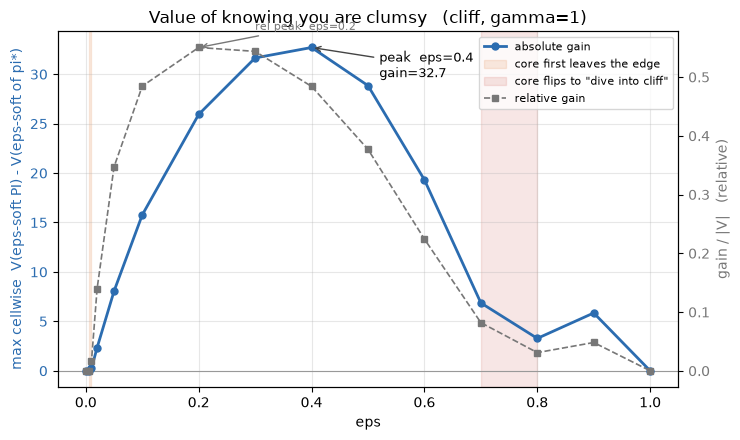

In [ ]:
import matplotlib.pyplot as plt

eps = [x.eps for x in results]
gain = [x.gain for x in results]
rel = [x.gain / x.absA if x.absA else 0.0 for x in results]
peak = max(range(len(gain)), key=lambda i: gain[i])
peak_rel = max(range(len(rel)), key=lambda i: rel[i])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(eps, gain, 'o-', color='#2b6cb0', lw=2, ms=5, zorder=3, label='absolute gain')
ax.axhline(0, color='#999', lw=0.8)

# the two structural boundaries
ax.axvspan(0.005, 0.01, color='#e07b39', alpha=0.15, label='core first leaves the edge')
ax.axvspan(0.7, 0.8, color='#c0392b', alpha=0.12, label='core flips to "dive into cliff"')

ax.annotate(
    f'peak  eps={eps[peak]}\ngain={gain[peak]:.1f}',
    xy=(eps[peak], gain[peak]),
    xytext=(eps[peak] + 0.12, gain[peak] - 3),
    arrowprops=dict(arrowstyle='->', color='#444'),
    fontsize=9,
)

ax2 = ax.twinx()
ax2.plot(eps, rel, 's--', color='#777', ms=4, lw=1.2, zorder=2, label='relative gain')
ax2.set_ylabel('gain / |V|   (relative)', color='#777')
ax2.tick_params(axis='y', labelcolor='#777')
ax2.annotate(
    f'rel peak  eps={eps[peak_rel]}',
    xy=(eps[peak_rel], rel[peak_rel]),
    xytext=(eps[peak_rel] + 0.10, rel[peak_rel] + 0.03),
    arrowprops=dict(arrowstyle='->', color='#777'),
    fontsize=8,
    color='#777',
)

ax.set_xlabel('eps')
ax.set_ylabel('max cellwise  V(eps-soft PI) - V(eps-soft of pi*)', color='#2b6cb0')
ax.tick_params(axis='y', labelcolor='#2b6cb0')
ax.set_title('Value of knowing you are clumsy   (cliff, gamma=1)')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


In [ ]:
# Trace the tail finely: where does the dip at eps~0.78 come from?
# Per-cell gain for four representative cells, plus the greedy core of row 2.
print(' eps  | g(2,0) g(2,5) g(3,0) g(0,0) |  max  | row 2 core')
print('------+----------------------------+-------+-------------')
for e in [0.6, 0.65, 0.7, 0.72, 0.74, 0.75, 0.76, 0.78, 0.8, 0.85, 0.9, 0.95, 1.0]:
    A, A_conv = silent(policy_evaluation)(cliff, eps_soft(cliff, pi_star, e), gamma=1.0)
    P, B, B_conv = silent(policy_iteration)(
        cliff, [r[:] for r in pi_star], eps=e, gamma=1.0
    )
    assert A_conv and B_conv, f"did not converge at eps={e}"

    gain_at = lambda r, c: B[r][c] - A[r][c]
    mx = max(gain_at(r, c) for r in range(cliff.rows) for c in range(cliff.cols))
    core = ''.join(
        cliff.arrows[max(P[2][c], key=P[2][c].get)] for c in range(cliff.cols)
    )
    print(
        f'{e:5} | {gain_at(2, 0):6.2f} {gain_at(2, 5):6.2f} '
        f'{gain_at(3, 0):6.2f} {gain_at(0, 0):6.2f} | {mx:5.2f} | {core}'
    )


 eps  | g(2,0) g(2,5) g(3,0) g(0,0) |  max  | row 2 core
------+----------------------------+-------+-------------
  0.6 |  19.31  14.74  15.17  10.94 | 19.31 | ↑↑↑↑↑↑↑↑↑↑→↓
 0.65 |  12.48  10.84   9.47   8.10 | 12.48 | ↑↑↑↑↑↑↑↑↑↑→↓
  0.7 |   5.90   6.86   4.31   4.68 |  6.86 | ↑↑↑↑↑↑↑↑↑↑→↓
 0.72 |   3.90   5.48   2.80   3.58 |  5.51 | ↑↑↑↑↑↑↑↑↑→→↓
 0.74 |   2.04   4.15   1.44   2.47 |  4.32 | ↑↑↑↑↑↑↑↑↑→→↓
 0.75 |   1.59   3.51   1.65   2.00 |  3.73 | →→↑↑↑↑↑↑↑→→↓
 0.76 |   1.41   2.89   1.97   1.62 |  3.15 | →→→↑↑↑↑↑↑→→↓
 0.78 |   1.42   1.74   2.62   1.11 |  2.62 | →↓→→↑↑↑↑↑→→↓
  0.8 |   1.89   0.79   3.28   0.98 |  3.28 | ↓↓↓→→↑↑↑↑→→↓
 0.85 |   4.05   0.26   4.67   3.65 |  4.67 | ↓↓↓↓↓→→→→→→↓
  0.9 |   5.04   1.21   4.82   5.85 |  5.85 | ↓↓↓↓↓↓→→→→→↓
 0.95 |   3.86   1.67   3.35   4.82 |  4.82 | ↓↓↓↓↓↓↓↓→→→↓
  1.0 |   0.00   0.00   0.00   0.00 |  0.00 | ↓↓↓↓↓↓↓↓↓→→↓


## The tail: one curve, two mechanisms

`gain(eps)` is not a single smooth hump. It peaks at eps=0.4, falls to a **local minimum around
eps=0.78**, rises again by 0.9, and only then goes to zero at eps=1. The `cell` column of
`results` moves at exactly those points — `(2,0)` -> `(2,5)` -> `(3,0)` -> `(0,0)` — which is the
tell: the maximum is being handed off between cells that are benefiting for different reasons.

`gain(eps)` is the **upper envelope of two separate mechanisms**:

- **the flee benefit** — best seen at `(2,5)`. Routing up and away from the edge instead of
  walking it. Large at small eps, decays to 0.26 by eps=0.85.
- **the dive benefit** — best seen at `(3,0)`, later `(0,0)`. Ending the episode at -100 rather
  than bleeding -1 per step through a long random walk. Switches on around eps=0.78 and rises.

Where the first has run out and the second has not yet started, neither is worth much, and the
max dips. That is the minimum at eps~0.78 — a crossover, not a smooth turning point.

### The core passes back through pi* on its way

The interesting part is that row 2's core does not go `up` -> `down`. It goes
**`up` -> `right` -> `down`**:

```-
0.74   ^^^^^^^^^>>v     flee upward, away from the edge
0.75   >>^^^^^^^>>v     (2,0) and (2,1) revert to walking the edge
0.78   >v>>^^^^^>>v     (2,1) is the first cell to dive
0.80   vvv>>^^^^>>v     the dive spreads rightward
```

That middle stage **is pi\*'s behaviour**. So on its way from "flee" to "dive", the eps-soft
optimum passes back through the very plan it was improving on — and wherever it agrees with pi\*,
`B == A` and the gain collapses. The dip is not an artifact of taking a max over cells. It is the
eps-soft optimum briefly rediscovering pi\*.

The headline, and the most transferable thing in this block:

> **The same policy can be optimal for two unrelated reasons at two different eps, and be wrong
> in between.**

At eps=0, walking the edge is optimal *because you will not fall*. At eps~0.75 it is optimal
*because you are going to die either way, so take the short path*. Two arguments with nothing in
common, landing on the same arrows.

### Caveat

Everything above eps~0.7 depends on this grid's cliff being **terminal**. In the textbook Cliff
Walking, falling teleports you back to the start — you pay -100 *and keep going* — so ending the
episode early is never a strategy. Under that version the dive regime does not exist, and neither
does this dip. Do not cite the tail as a Cliff Walking result; the flee regime (eps <= 0.5) is the
part that transfers.


### Why `(2,0)` -> `(2,5)` -> `(3,0)` -> `(0,0)`

Four phases, two mechanisms. gain(s) measures how much a smarter plan is worth starting from s, so it's largest where π*'s plan hurts most and a better alternative is actually available from there.

Phase 1, (2,0), ε ≤ 0.6 — flee, maximum exposure.

π*'s core is → in all three rows with a ↓ at column 11. So from (2,0) the plan is: walk all 11 cells of the cliff edge. Each one carries an ε/4 chance of stepping down and dying, and the risk compounds over the whole traversal. (2,0) is the cell with the most edge-steps still ahead of it, so it's the cell π* damages most under smearing — and B avoids essentially all of it by climbing. Cells further right have fewer remaining edge steps. Rows 0 and 1 are barely exposed at small ε, since reaching the cliff from there needs several wrong actions in a row.

Phase 2, (2,5), ε ≈ 0.7–0.76 — same mechanism, shrinking support.

This one isn't a new mechanism, it's the old one surviving only in the middle. Look at the core:


0.74   ↑↑↑↑↑↑↑↑↑→→↓
0.76   →→→↑↑↑↑↑↑→→↓     (2,0)-(2,2) have reverted to pi*'s edge-walk
Where B agrees with π*, B == A and the gain is zero by construction — g(2,0) collapses from 5.90 at ε=0.7 to 1.41 at ε=0.76. The argmax moves to the middle of the band that's still fleeing.

Why do the left cells give up first? The flee detour from (2,0) is the longest one — climb two rows, traverse eleven columns, come back down. At ε=0.75 you get knocked off course so often that the detour's extra length costs more than the fall risk it avoids. Same ordering as phase 1, sign flipped: the leftmost cell has the most to gain from fleeing at low ε, and the most to lose from it at high ε.

Phase 3, (3,0), ε ≈ 0.78–0.85 — the dive switches on where it's cheapest.

Verified: (3,0)'s core flips from ↑ to → at exactly ε=0.78, and → from (3,0) lands on (3,1), a cliff cell. (3,0) is the only non-terminal cell in row 3 — it's the one place in the grid that can terminate in a single step. So when "stop the bleeding" first becomes worth it, that's where it pays first and biggest.

Phase 4, (0,0), ε ≥ 0.85 — the dive matures, and the prize goes to the most remote cell.

(0,0)'s core flips → to ↓ at ε=0.85. (0,0) is the farthest cell from any terminal in the grid — three rows up and eleven columns from the goal — so under A it accumulates the most −1 steps before anything ends. A(0,0) = -121.51 at ε=0.9, the most negative value on the board. Most bleeding to stop, most to save by stopping it.

The unifying line: at low ε the enemy is the cliff, so the gain concentrates where cliff risk is highest. At high ε the enemy is the clock, so it concentrates where time-to-terminal is longest. The argmax walking (2,0) → (2,5) → (3,0) → (0,0) is that handover, cell by cell — from the most dangerous square on the board to the most remote one.